# What's so great about Linear Algebra? # 

With any exposure to quantum mechanics, you've probably heard a lot about "linear algebra" and "linear operators". Our goal today is to give a crash-course introduction to what these terms are all about and what's so special about the *linear* part of quantum mechanics. 

## Quantum states are vectors ##

The point of fundamental departure between quantum and classical mechanics is that in quantum mechanics, the most fundamental description of any system's state is a *vector* -- a sequence of numeric elements correspond to different possible physical properties or measurement outcomes. 

For example, the first key discovery on which quantum theory was constructed is that the energy states of harmonic oscillators (think: a molecular bond) are *quantized*, i.e., the energies must take one of a discrete set of values, as illustrated in the image below.  

<div>
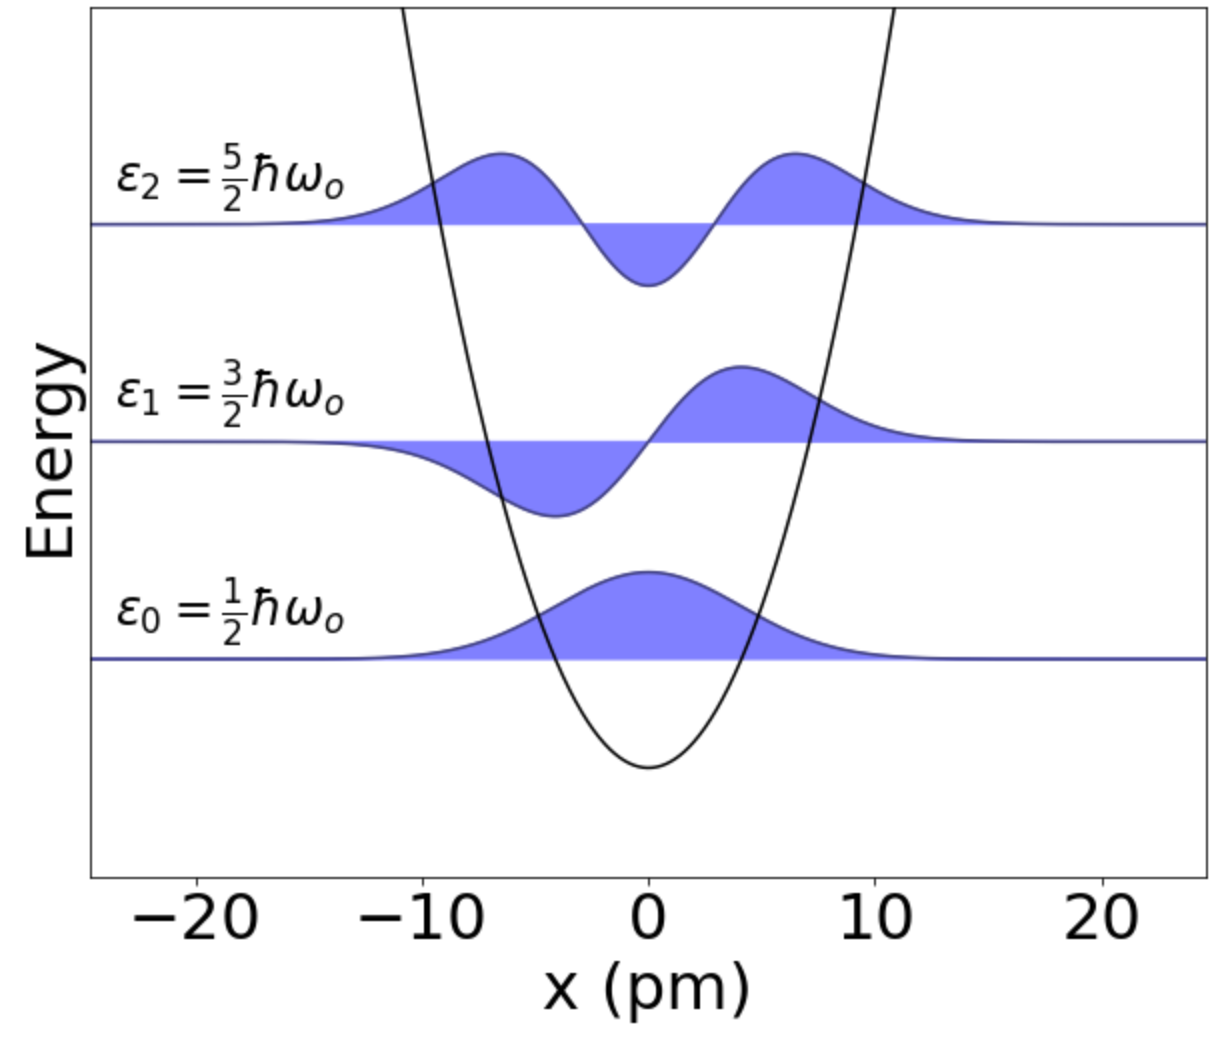
</div>

The blue curves here represent different physical states of the system (numbered $n = 1, 2, 3...$) corresponding to different possible energies the system could have. (There are more possible states even higher in energy, but we're only showing three in this example.) In general, though, the system doesn't need to be *only* in the $n = 0$ state or the $n = 1$ state. It could have some contribution from both or from any other combination of states. 

In general, we can represent the state of any quantum system using a *vector* of numbers
$$ \left | \psi \right> = \begin{bmatrix} a_0 \\ a_1 \\ a_2 \\ \vdots \end{bmatrix}$$
that indicate the *amplitude* of each possible energy state. 

As it turns out, the *probability* to find the system in the $n^{th}$ energy state is just $|a_n|^2$. But that's getting a little ahead of ourselves. For now all you need to know is that the vector elements $a_n$ tell us something about how much our system "looks like" a given physical state, e.g., an energy level. 


### Vectors in NumPy ##

NumPy is a very useful package for **Num**erical calculations in **Py**thon. Basic NumPy syntax for defining vectors is illustrated below. 

In [1]:
import numpy as np

# Define a vector
psi = np.array([0.5, 0.1, 0.25])

# Note that the "shape" is "(3,)" meaning it has 3 "rows" and no "columns". 
print(np.shape(psi))

# NumPy can also be used to define matrices of 2 or more dimensions, as we'll
# see later. A "vector" in NumPy corresponds to an array with dimension (N,).

# print the vector
print(psi)

(3,)
[0.5  0.1  0.25]


## Quantum vectors live in an *inner product* space. ##

One  of the defining feature of vectors is that they can be added and subtracted to produce new vectors. E.g., 

$$\begin{bmatrix} a_0 \\ a_1 \\ \vdots \end{bmatrix} + \begin{bmatrix} b_0 \\ b_1 \\ \vdots \end{bmatrix} = \begin{bmatrix} a_0 + b_0 \\ a_1 + b_1 \\ \vdots \end{bmatrix}$$

And they can be multiplied by scalars: 
$$\alpha \begin{bmatrix} a_0 \\ a_1 \\ \vdots \end{bmatrix}= \begin{bmatrix} \alpha a_0 \\ \alpha a_1 \\ \vdots \end{bmatrix}$$

Quantum state vectors have both of these properties and more. In particular, quantum states live in an **inner product space**, meaning that there is a well-defined operation for multiplying two vectors to get a scalar. If $\left | \psi \right> $ and $\left | \phi \right>$ are two vectors with elements $a_0, a_1, ...$ and $b_0, b_1, ...$, then their inner product is:
$$\left < \psi | \phi \right> = \begin{bmatrix} a_0^* & a_1^* & \cdots \end{bmatrix} \begin{bmatrix} b_0 \\ b_1 \\ \vdots \end{bmatrix} = a_0^* b_0 + a_1^* b_1 + \dots$$

In three-dimensional real-space, the "inner product" is exactly the same as the "dot product". But the notion of "inner product" is much more general than 3D Euclidean space. In quantum mechanics, vectors are generally *complex* and *infinite-dimensional*! This is why we include the "\*" in the definition of $\left < \psi | \phi \right>$ -- in complex vector spaces, it turns out to be more meaningful to take the complex conjugate of the first vector's elements when calculating inner products. 

### Inner products in NumPy ### 

NumPy has a couple of different built-in functions for calculating dot products. 
* `np.dot()` calculations the dot product *without* taking the complex conjugate of the first vector. This is usually the right operation for real-valued vectors. 
* `np.vdot()` calculates the correct inner product for complex vectors (i.e., it takes the complex conjugate of the first vector before multiplying and adding the elements). 


In [66]:
# Define three vectors
psi = np.array([1, 0])
phi = np.array([0, 1])
chi = np.array([1, -1j])

# Check their dot products:
print('np.dot(psi, phi):', np.dot(psi, phi))
print('np.dot(phi, chi):', np.dot(phi, chi))
print('np.dot(chi, phi):', np.dot(chi, phi))
print('np.vdot(chi, phi):', np.vdot(chi, phi))


np.dot(psi, phi): 0
np.dot(phi, chi): -1j
np.dot(chi, phi): -1j
np.vdot(chi, phi): 1j


## Inner products are linear ##

The unique importance of linear *operators* in quantum mechanics (which we haven't yet explained...) stems from the fact that **the inner product is linear**, meaning two things:
1. $$\left < \phi \right | \left( \alpha \left | \psi \right> \right) = \alpha \left < \phi | \psi \right> $$

and 

2. $$\left < \phi \right | \left( \left | \psi \right> +  \left | \chi \right> \right) = \left < \phi | \psi \right> + \left < \phi | \chi \right> $$

These properties are easy to verify from the definition of the inner product we just gave. We can also illustrate them numerically using NumPy: 

In [67]:
print('np.vdot(chi, phi):', np.vdot(chi, phi))
print('np.vdot(chi, psi):', np.vdot(chi, psi))
print('np.vdot(chi, phi+psi):', np.vdot(chi, phi+psi))
print('np.vdot(chi, 2.0*(phi+psi)):', np.vdot(chi, 2.0*(phi+psi)))

np.vdot(chi, phi): 1j
np.vdot(chi, psi): (1+0j)
np.vdot(chi, phi+psi): (1+1j)
np.vdot(chi, 2.0*(phi+psi)): (2+2j)


## Inner products define length ##

An important property of the inner product is that the inner product of a vector with itself is *always a positive number*: 
$$ \left < \psi | \psi \right>  = a_0^* a_0 + a_1^* a_1 + ... = \left | a_0 \right |^2 + \left | a_1 \right |^2 + ... > 0$$
As a consequence, it is possible to think of the inner product as defining the **length** of a vector; more specifically, we say the length of a vector in an inner-product space is 
$$ \left \| \psi \right \| = \sqrt{\left < \psi | \psi \right >} .$$

In abstract inner-product spaces, we usually call this "length" by the more technical name of "norm". In NumPy, you can calculate vector norms using the ``np.linalg.norm()`` function. 

In [68]:
print('|psi|:', np.linalg.norm(psi))
print('|phi|:', np.linalg.norm(phi))
print('|chi|:', np.linalg.norm(chi))
print('|phi+psi|:', np.linalg.norm(phi+psi))

|psi|: 1.0
|phi|: 1.0
|chi|: 1.4142135623730951
|phi+psi|: 1.4142135623730951


## Inner products define *distance* ##

Once we have a notion of "length" in abstract vector space, it is easy to think about *distance* in exactly the same way we do in real 3D Euclidean space: The "distance" between two vectors is the length (or norm) of their difference:

$$ \| \psi - \phi \| = \sqrt{\left < \psi - \phi | \psi - \phi \right> }$$

Note that this works even for complex vectors! Because the norm is always a real, positive number, the distance is also always real and positive. 

In [69]:
print('| phi - psi|:', np.linalg.norm(phi-psi))
print('| phi - chi|:', np.linalg.norm(phi-chi))

| phi - psi|: 1.4142135623730951
| phi - chi|: 1.7320508075688772


## Inner products define *projections* ##

Along with the concepts of "length" and "distance" comes the notion of alignment or projection, answering questions such as: How closely do two vectors align? 
or How much does one vector contribute to another? 

The starting point for this notion is the idea that vectors can be "orthogonal". Formally, two vectors are orthogonal if their inner product is zero, i.e., if $\left < \phi | \psi \right> = 0$. Intuitively, this corresponds to vectors that "point in different directions". 

Similarly, we say that two vectors are *orthonormal* if they are orthogonal and both vectors have unit norm, i.e., $\left < \phi | \phi \right> = 1$ and $\left < \psi | \psi \right> = 1$. 

These concepts, in turn, leads us to the notion of *projection*, a measure of just *how much* one vector contributes to another. Suppose that $\left | \phi \right >$ and $\left | \psi \right>$ are two orthogonal vectors so that $\left < \phi | \psi \right> = 0$. Suppose that some third vector $\left | \chi \right>$ is a linear combination of $\left | \phi \right>$ and $\left | \psi \right>$:

$$ \left | \chi \right > = \alpha \left | \phi \right> + \beta \left | \psi \right > $$

Then thanks to the linearity of inner products

$$ \left < \phi | \chi \right> = \left < \phi \right| \left( \alpha \left | \phi \right> + \beta \left | \psi \right > \right) = \alpha \left < \phi | \phi \right> + \beta \left < \phi | \psi \right> = \alpha .$$
And similarly 
$$ \left < \phi | \chi \right> = \beta . $$

Why is this useful? Because if we have an orthonormal set of vectors, it allows us to calculate *uniquely* how much each of these vectors contributes to any arbitrary vector $\left | \chi \right >$. The part of $\left | \chi \right>$ that points in the same direction as any one of the orthonormal vectors is called its *projection* along that vector. 

The NumPy code below illustrates how this works with real vectors in 2D. 

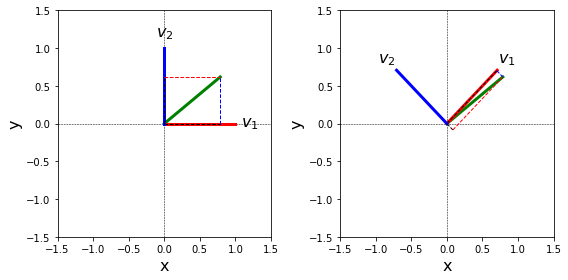

In [228]:
# This is a library useful for plotting vectors in 2D
import matplotlib.pyplot as plt 

# This just sets up the usual x-y axes in 2D
def set_up_axes(lim):
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.plot([-lim, lim], [0, 0], 'k--', linewidth=0.5)
    plt.plot([0,0], [-lim,lim], 'k--', linewidth=0.5)
    plt.xlabel('x', fontsize=16)
    plt.ylabel('y', fontsize=16)
    
    
# This will draw a line from start_point ==> start_point + vec. 
def draw_line(start_point, vec, flags, lw):
    plt.plot(start_point[0] + np.array([0, vec[0]]), start_point[1] + np.array([0, vec[1]]), flags, linewidth=lw)
    
# This decomposes the vector into a given basis set
def decompose(vec, basis):
    
    colors = ['r', 'b']
    
    draw_line(np.zeros((2,)), vec, 'g', 3.0)
    
    # Draw basis vectors
    for b, bvec in enumerate(basis):
        # This is the projection of vec on bvec: 
        proj = np.vdot(vec, bvec)*bvec
        
        # This plots the basis vector for comparison. 
        draw_line(np.zeros(2,), bvec, colors[b], 3.0)
        
        # This plots the projection. 
        draw_line(np.zeros((2,)), proj, 'k--', 1.0)
        
        # This plots the part that is *not* projected on this basis vector. 
        draw_line(proj, vec-proj, colors[(b+1)%2]+'--', 1.0)
        
        
        plt.text(bvec[0]*1.2, bvec[1]*1.2, '$v_' + str(b+1)+'$', ha='center', va='center', fontsize=16)
    


# Generate a random vector
chi = 2.0*np.random.random(size=(2,)) - np.ones((2,))
chi /= np.linalg.norm(chi)

plt.figure(figsize=(8,4))

# First let's decompose along the usual x and y axes
phi = np.array([1,0])
psi = np.array([0,1])
basis = [phi, psi]

plt.subplot(1,2,1)
set_up_axes(1.5)
decompose(chi, basis)


# Now let's compare with a different set of vectors
phi = np.array([1,1])/np.sqrt(2.0)
psi = np.array([-1,1])/np.sqrt(2.0)
basis = [phi, psi]

plt.subplot(1,2,2)
set_up_axes(1.5)
decompose(chi, basis)

plt.tight_layout()
plt.show()

## Inner projects allow us to construct orthonormal basis sets ##

With the concept of projections, we can finally talk formally about *basis* sets. An *orthonormal basis* is a set of orthonormal vectors large enough that *any other vector* in the inner-product space can be represented as a sum of the basis vectors. A defining feature of the particular type of inner-product space used in quantum mechanics (a "Hilbert space") that there always exists a *countable* orthonormal basis. 

In other words, we can always find a list of vectors that can be "counted off" one-by-one ($\left | \phi_0 \right>$, $\left | \phi_1 \right>$, $\left | \phi_2 \right>$, ...) that are normalized, mutually orthogonal, and "span" the entire vector space, i.e., so that any arbitrary vector $\left| \chi \right>$ can be written as a sum
$$ \left | \chi \right> = \left < \phi_0 | \chi \right> \left | \phi_0 \right> + \left < \phi_1 | \chi \right> \left | \phi_1 \right> + \dots $$

To keep the notation short, we often denote the basis vectors as simply $\left | n \right>$ (for $n = 0, 1, 2, ...$) so that we can simply write
$$ \left | \chi \right> = \sum_n \left < n | \chi \right> \left | n \right> $$

The code block below shows how to build an orthonormal basis for 2D vectors by randomly generating vectors and subtracting off the parts that are parallel to each other (a process called *Graham-Schmidt Orthogonalization*). 

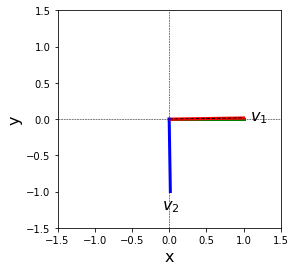

In [236]:
# Generate a random vector
phi = 2.0*np.random.random(size=(2,)) - np.ones((2,))

# Normalize it
phi /= np.linalg.norm(phi)

# Generate another random vector
psi = 2.0*np.random.random(size=(2,)) - np.ones(2,)

# Subtract off the part parallel to phi
psi -= np.vdot(phi, psi)*phi

# Normalize what's left
psi /= np.linalg.norm(psi)

basis = [phi, psi]

chi = np.array([1.0, 0.0])

plt.figure(figsize=(4,4))
set_up_axes(1.5)
decompose(chi, basis)
plt.show()

## Operators map vectors to vectors ##

With this introduction to vectors and inner products, we're ready to talk about operators. Briefly, an **operator** is something like a function, but for vectors: You feed in a vector as input, and it spits out a (usually) different vector as output. Formally, an operator is a "mapping" from vectors to other vectors. 

A few quick examples:
* We could define an operator that **adds an offset** to whatever vector we provide

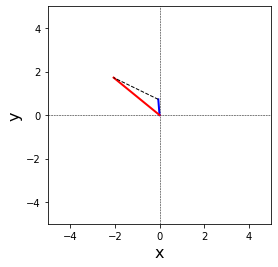

In [305]:
plt.figure(figsize=(4,4))
set_up_axes(5)

chi = np.random.random(size=(2,))*2 - np.ones((2,))

offset = np.array([-2,1])

# The original vector is in blue
draw_line(np.zeros(2,), chi, 'b', 2.0)

# The offset vector is in red
draw_line(np.zeros(2,), chi+offset, 'r', 2.0)

# The dashed line shows the offset itself
draw_line(chi, offset, 'k--', 1.0)

plt.show()

* We could define an operator that **squares the elements** of any given vector

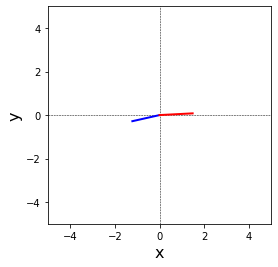

In [330]:
plt.figure(figsize=(4,4))
set_up_axes(5)

chi = np.random.random(size=(2,))*3 - 1.5*np.ones((2,))

# The original vector is in blue
draw_line(np.zeros(2,), chi, 'b', 2.0)

# The offset vector is in red
draw_line(np.zeros(2,), chi**2, 'r', 2.0)

plt.show()

* Or we could define an operator that **scales any given vector** we provide. 

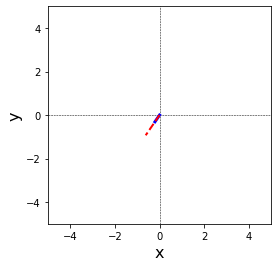

In [354]:
plt.figure(figsize=(4,4))
set_up_axes(5)

chi = np.random.random(size=(2,))*2 - np.ones((2,))

scale = 3.0

# The original vector is in blue
draw_line(np.zeros(2,), chi, 'b', 3.0)

# The offset vector is in red
draw_line(np.zeros(2,), scale*chi, 'r--', 2.0)
plt.show()

* Or an operator that **rotates any given vector** we provide. 

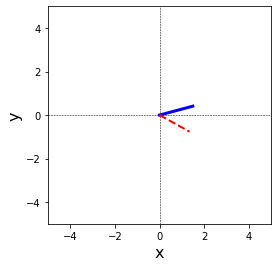

In [383]:
plt.figure(figsize=(4,4))
set_up_axes(5)

chi = np.random.random(size=(2,))*4 - 2*np.ones((2,))

theta = 45.0*np.pi/180.0
RMat = np.array([
    [np.cos(theta), np.sin(theta)],
    [-np.sin(theta), np.cos(theta)]
])

# The original vector is in blue
draw_line(np.zeros(2,), chi, 'b', 3.0)

# The offset vector is in red
draw_line(np.zeros(2,), RMat@chi, 'r--', 2.0)
plt.show()

## *Linear* operators follow the same rules as inner products ##

A **linear** operator is a special class of operator that obeys the same two "linearity" rules we saw earlier for inner products: 
1. $\hat A \left( \left | \psi \right> + \left | \phi \right>  \right) = \hat A \left | \psi \right> + \hat A \left | \phi \right> $
2. $ \hat A ( \alpha \left | \psi \right> = \alpha \hat A \left | \psi \right> $. 

Which of the four operator examples we just gave do you think were linear? (Hint: two are linear and two are not.)


## Linear operators can be *decomposed* using inner products ##

Because linear operators follow the same linearity rules as inner products, they can likewise be decomposed into elements corresponding to different orthonormal basis vectors. Formally, if $\{ \left | 0 \right> $, $\left | 1 \right> $, $\left | 2 \right> $, ...$\}$ form an orthonormal basis then (because $\hat A$ is linear):
$$ \hat A \left | \psi \right > = \hat A \sum_n \left < n | \psi \right> \left | n \right> = \sum_n \hat A \left | n \right> \left < n | \psi \right> . $$

Each of the new vectors $\hat A \left | n \right>$ can *also* be decomposed in the same basis as 
$$ \hat A \left | n \right> = \sum_m \left | m \right> \left < m \right | \hat A \left | n \right> . $$

This lets us write the entire operation as:

$$ \hat A \left | \psi \right > = \sum_{m,n} \left | m \right> \left < m \right | \hat A \left | n \right> $$

The number

$$ A_{mn} = \left < m \right | \hat A \left | n \right> $$

is called a *matrix element* of $\hat A$ and can be used to define a matrix of numbers that *completely specify* what $\hat A$ does to vectors. In fact, if $\left | \psi \right>$ is represented in vector form as 
$$ \left | \psi \right> = \begin{bmatrix} c_0 \\ c_1 \\ c_2 \\ \vdots \end{bmatrix}$$
then 
$$ \hat A \left | \psi \right> = \begin{bmatrix} A_{00} & A_{01} & A_{02} & \cdots \\ A_{10} & A_{11} & A_{12} & \cdots \\ A_{20} & A_{21} & A_{22} & \cdots \\ \vdots & \vdots & \vdots & \ddots \\\end{bmatrix} \begin{bmatrix} c_0 \\ c_1 \\ c_2 \\ \vdots \end{bmatrix} .$$

Thus every linear operator can be uniquely defined by a square matrix. And clearly every square matrix also defines a linear operator. There is thus a one-to-one mapping between linear operators and matrices!

Note, however, that this *only works for linear operators*. Nonlinear operations (such as squaring the elements of a vector) are *not* representable by simple matrix-vector products. 